# 1) Install/Import packages

In [ ]:
!pip install numpy shapely matplotlib pandas aif360 plotly scikit-learn catboost pytorch_tabnet xgboost

In [1]:
import sys
sys.path.append("../")
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from Fairea.fairea import create_baseline,normalize,classify_region,compute_area
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams.update({'font.size': 12})
import pandas as pd
from aif360.datasets import BinaryLabelDataset

# 2) Generate baseline

To evaluate bias mitigation methods using the FAIREA approach, the first step is to generate a baseline that represents the trade-off between fairness and accuracy for naive solutions.

In [2]:
dataset_used = "diabetes"
clf_name = "cat"

degrees = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
mutation_strategies = {"0":[1,0],"1":[0,1]}

label_name = 'readmitted'
sensitive_attribute = ['age']

privileged_groups = [{'age': 1}]
unprivileged_groups = [{'age': 0}]

data = pd.read_csv('../data/diabetes_pre/diabetes.csv')

dataset_orig = BinaryLabelDataset(
    df=data,
    label_names=[label_name],
    protected_attribute_names = sensitive_attribute,
    favorable_label = 1,
    unfavorable_label = 0
)

In [3]:
res = create_baseline(clf_name, dataset_orig, privileged_groups,unprivileged_groups,
                    data_splits=5,repetitions=5,odds=mutation_strategies,options = [0,1],
                   degrees = degrees)

0:	learn: 0.6180000	total: 150ms	remaining: 44.8s
1:	learn: 0.5596525	total: 184ms	remaining: 27.4s
2:	learn: 0.5128878	total: 209ms	remaining: 20.7s
3:	learn: 0.4749716	total: 226ms	remaining: 16.7s
4:	learn: 0.4477697	total: 242ms	remaining: 14.3s
5:	learn: 0.4249976	total: 255ms	remaining: 12.5s
6:	learn: 0.4076090	total: 266ms	remaining: 11.1s
7:	learn: 0.3942243	total: 276ms	remaining: 10.1s
8:	learn: 0.3830511	total: 290ms	remaining: 9.37s
9:	learn: 0.3738287	total: 300ms	remaining: 8.7s
10:	learn: 0.3668644	total: 312ms	remaining: 8.2s
11:	learn: 0.3605947	total: 321ms	remaining: 7.7s
12:	learn: 0.3563885	total: 329ms	remaining: 7.27s
13:	learn: 0.3532518	total: 338ms	remaining: 6.9s
14:	learn: 0.3506369	total: 347ms	remaining: 6.59s
15:	learn: 0.3480926	total: 357ms	remaining: 6.34s
16:	learn: 0.3460951	total: 368ms	remaining: 6.12s
17:	learn: 0.3442651	total: 376ms	remaining: 5.9s
18:	learn: 0.3428242	total: 385ms	remaining: 5.7s
19:	learn: 0.3414653	total: 397ms	remaining: 5.

Obtain accuray (index 0 of each row) and fairness (SPD is index 1, AOD is index 2, CFS is index 3) for each overwriting strategy

In [4]:
acc0 = np.array([np.mean([row[0] for row in res["0"][degree]]) for degree in degrees])
acc1 = np.array([np.mean([row[0] for row in res["1"][degree]]) for degree in degrees])

spd0 = np.array([np.mean([row[3] for row in res["1"][degree]]) for degree in degrees])
spd1 = np.array([np.mean([row[3] for row in res["1"][degree]]) for degree in degrees])

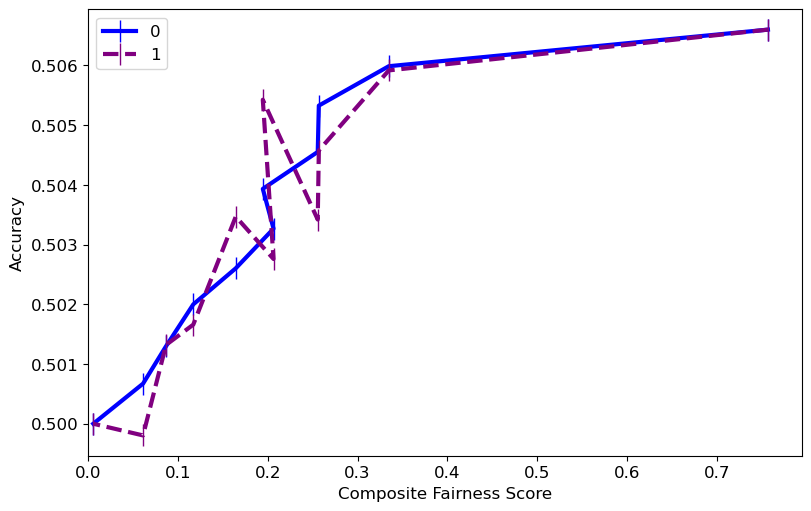

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5),constrained_layout=True)
axes.plot(spd0,acc0,color="blue",marker = "|", linestyle = "solid",linewidth=3,markersize=16)
axes.plot(spd1,acc1,color="purple",marker = "|", linestyle = "dashed",linewidth=3,markersize=16)
axes.set_xlim(0)
axes.set_xlabel("Composite Fairness Score")
axes.set_ylabel("Accuracy")
axes.legend(mutation_strategies.keys())

Among those two strategies, "0" is the stricter (higher accuracy for identical value of CFS) and will be used in the following

# 3) Determine mitigation region
To determine the mitigation region of bias mitigation methods, we perform three steps:

1. Normalize the data
2. Determine region
3. Compute area of "good trade-off region"

In [6]:
import pandas as pd
df = pd.read_csv('../../../experiments_intersec/diabetes_age_agg.csv')
df_cleaned = df.dropna()
df_cleaned.head()

,model_clean,BM,balanced_acc,acc,precision,recall,f1,mcc,eq_opp_diff,avg_odd_diff,spd,disparate_impact,theil_idx,fair_score,model_type
1,RandomForestClassifier,baseline,0.595310,0.633467,0.162667,0.546106,0.250668,0.041761,-0.156700,-0.035813,0.065477,1.209327,0.111166,0.584,tree_bag
2,MLPClassifier,baseline,0.540735,0.565729,0.130876,0.508505,0.208173,0.058169,0.008660,0.067378,0.116374,1.361101,0.116359,0.595,nn
3,CatBoostClassifier,baseline,0.631717,0.684221,0.191781,0.564011,0.286234,0.051349,-0.138469,-0.017299,0.085519,1.347009,0.106612,0.629,tree_boost
4,TabNetClassifier,baseline,0.600525,0.560804,0.154598,0.651746,0.249914,0.026272,-0.049134,0.061276,0.154263,1.478668,0.099312,0.706,tabnet
5,LogisticRegression,baseline,0.603368,0.642915,0.168120,0.552372,0.257781,0.035365,-0.048496,0.058741,0.149261,1.670085,0.110111,0.787,linear


{'RandomForestClassifier': (0.2759890332046141, 0.5497003076207491), 'MLPClassifier': (0.6897123158865798, 0.535164962948085), 'CatBoostClassifier': (0.0, 0.4902375339598507), 'TabNetClassifier': (0.23645918543541702, 0.3884901212512025), 'LogisticRegression': (0.21622922239996203, 0.21406598517923406), 'XGBClassifier': (0.1491444527208875, 0.22727993488165593), 'AdversarialDebiasing': (0.3780547127213434, 0.0)}
[1.         0.43802231 0.33431415 0.33270656 0.25128626 0.26719223
 0.21119933 0.14821943 0.10784272 0.07376747 0.        ]
[0.         0.10048106 0.29787859 0.4680279  0.17284748 0.56524056
 0.46078427 0.72697649 0.77689919 1.         0.97118146]


Text(0, 0.5, 'Accuracy')

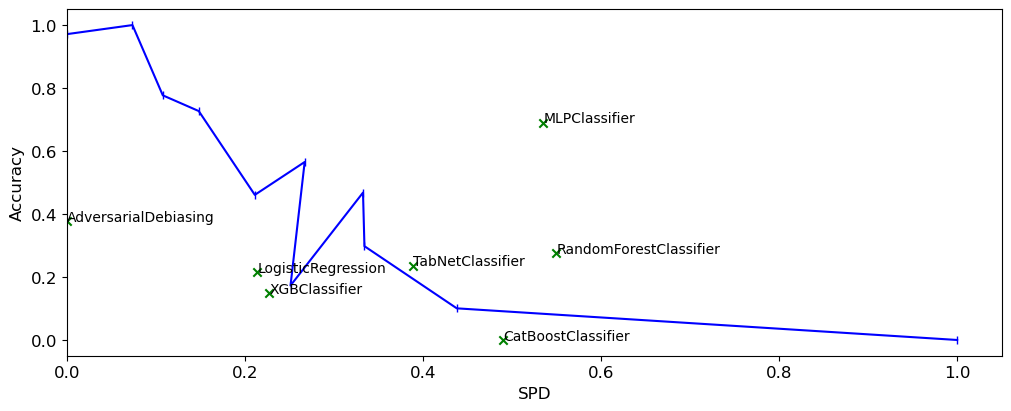

In [7]:
key_list = df_cleaned.model_clean.to_list()
acc_list, fair_list = df_cleaned.balanced_acc.to_list(), 1-df_cleaned.fair_score.to_numpy()
methods = {key: (float(val1), float(val2)) for key, val1, val2 in zip(key_list, acc_list, fair_list)}

normalized_accuracy, normalized_fairness, normalized_methods = normalize(acc1, spd1, methods)

print(normalized_methods)
print(normalized_fairness)
print(normalized_accuracy)


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 4),constrained_layout=True)
axes.plot(normalized_fairness, normalized_accuracy,color="blue",marker = "|")

axes.scatter([x[1] for x in normalized_methods.values()],[x[0] for x in normalized_methods.values()],marker="x",color="green")
for k,v in normalized_methods.items():
    axes.annotate(k, (v[1], v[0]), fontsize=10)
axes.set_xlim(0)
axes.set_xlabel("SPD")
axes.set_ylabel("Accuracy")
#plt.show()

# 4) Display bias mitigation methods

We use experimental data from bias mitigation methods generated with the callmefair framework. For each bias mitigation method, "data" reports accuracy and CPS averaged over multiple different data splits.

In [8]:
from shapely.geometry import Polygon, Point, LineString
%matplotlib inline
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams.update({'font.size': 12})


In [10]:
x_th = max([min(acc0), min(acc1)])
y_th = min([max(spd0), max(spd1)])

def plot_tradeoff(df, normalized_fairness=None, normalized_accuracy=None, normalized_methods=None,
                 x_split=x_th, y_split=y_th, diagonal_end=None,
                 region_colors=None, title="Accuracy vs Bias Trade-off Regions"):
    """
    Creates a trade-off plot with dynamic ranges and configurable regions
    If normalized data is provided, shows the actual baseline diagonal
    """
    # Calculate dynamic ranges with 5% padding
    x_min = max(0, df['fair_score'].min() - 0.05)
    x_max = min(1, df['fair_score'].max() + 0.05)
    y_min = max(0, df['balanced_acc'].min() - 0.05)
    y_max = min(1, df['balanced_acc'].max() + 0.05)

    # Set default diagonal end if not provided
    if diagonal_end is None:
        diagonal_end = (x_split, y_max)

    # Default colors with high transparency
    colors = {
        'win_win': 'rgba(0,200,0,0.1)',
        'good_tradeoff': 'rgba(100,200,100,0.1)',
        'poor_tradeoff': 'rgba(255,165,0,0.1)',
        'inverted': 'rgba(128,0,128,0.1)',
        'lose_lose': 'rgba(255,0,0,0.1)'
    }
    if region_colors:
        colors.update(region_colors)

    fig = go.Figure()

    # Region coordinates
    left_regions = {
        'base_x': x_min,
        'base_y': y_min,
        'split_x': x_split,
        'split_y': y_split,
        'diag_x': diagonal_end[0],
        'diag_y': diagonal_end[1]
    }

    # Add regions (order matters for layering)
    # Poor Trade-off (rectangle)
    fig.add_shape(type="rect",
        x0=left_regions['base_x'], y0=left_regions['base_y'],
        x1=left_regions['split_x'], y1=left_regions['split_y'],
        fillcolor=colors['poor_tradeoff'], layer="below")

    # Good Trade-off (triangle)
    fig.add_shape(type="path",
        path=f"M {left_regions['base_x']} {left_regions['split_y']} "
             f"L {left_regions['diag_x']} {left_regions['diag_y']} "
             f"L {left_regions['split_x']} {left_regions['split_y']} Z",
        fillcolor=colors['good_tradeoff'], layer="below")

    # Win-Win (triangle)
    fig.add_shape(type="path",
        path=f"M {left_regions['base_x']} {left_regions['split_y']} "
             f"L {left_regions['diag_x']} {left_regions['diag_y']} "
             f"L {left_regions['base_x']} {left_regions['diag_y']} Z",
        fillcolor=colors['win_win'], layer="below")

    # Right regions
    fig.add_shape(type="rect", x0=x_split, y0=y_split, x1=x_max, y1=y_max,
                 fillcolor=colors['inverted'], layer="below")
    fig.add_shape(type="rect", x0=x_split, y0=y_min, x1=x_max, y1=y_split,
                 fillcolor=colors['lose_lose'], layer="below")

    # Add the actual baseline diagonal if normalized data is provided
    if normalized_fairness is not None and normalized_accuracy is not None:
        # Transform normalized coordinates back to original scale for plotting
        # Note: This assumes the normalized data corresponds to the same scale as df
        fig.add_trace(go.Scatter(
            x=normalized_fairness,
            y=normalized_accuracy,
            mode='lines+markers',
            line=dict(color='red', width=3, dash='dash'),
            marker=dict(size=6, color='red'),
            name='Actual Baseline Diagonal',
            showlegend=True
        ))

    # Add normalized methods if provided
    if normalized_methods is not None:
        fig.add_trace(go.Scatter(
            x=[v[1] for v in normalized_methods.values()],
            y=[v[0] for v in normalized_methods.values()],
            mode='markers',
            marker=dict(size=8, color='orange', symbol='x'),
            name='Normalized Methods',
            text=list(normalized_methods.keys()),
            textposition="top center",
            showlegend=True
        ))

    # Add scatter plot
    fig.add_trace(go.Scatter(
        x=df['fair_score'], y=df['balanced_acc'],
        mode='markers', marker=dict(size=10, color='blue'),
        name='Models'))

    # Adjusted annotations
    annotations = [
        dict(x=(x_min + x_split)/2, y=.01+(y_split + y_max)/2,
             text="Win-Win", showarrow=False, font=dict(color='darkgreen')),
        dict(x=(x_min + x_split)/2, 
             y=y_split + (left_regions['diag_y'] - y_split)*0.3,  # Adjusted position
             text="Good Trade-off", showarrow=False, font=dict(color='green')),
        dict(x=(x_min + x_split)/2, y=y_min + (y_split - y_min)/2,
             text="Poor Trade-off", showarrow=False, font=dict(color='darkorange')),
        dict(x=(x_split + x_max)/2, y=(y_split + y_max)/2,
             text="Inverted", showarrow=False, font=dict(color='purple')),
        dict(x=(x_split + x_max)/2, y=y_min + (y_split - y_min)/2,
             text="Lose-Lose", showarrow=False, font=dict(color='darkred'))
    ]
    # Find the point with the lowest fairness score
    min_fair_score_row = df.loc[df['fair_score'].idxmin()]
    min_fair_score = min_fair_score_row['fair_score']
    max_acc = min_fair_score_row['balanced_acc']
    bm_technique = min_fair_score_row['BM']
    model = min_fair_score_row['model_clean']

    # Highlight the point with the lowest fairness score
    fig.add_trace(
        go.Scatter(
            x=[min_fair_score],
            y=[max_acc],
            mode='markers',
            marker=dict(size=15, color='red', symbol='star',line=dict(width=2,color='DarkSlateGrey')),
            name=f"Best Fairness<br>Model: {model}<br>BM: {bm_technique}",
            showlegend=True
        )
    )

    # Find the point with the highest accuracy score
    max_acc_row = df.loc[df['balanced_acc'].idxmax()]
    max_fair_score = max_acc_row['fair_score']
    max_acc = max_acc_row['balanced_acc']
    bm_technique = max_acc_row['BM']
    model = max_acc_row['model_clean']

    # Highlight the point with the highest acc score
    fig.add_trace(
        go.Scatter(
            x=[max_fair_score],
            y=[max_acc],
            mode='markers',
            marker=dict(size=15, color='green', symbol='star', line=dict(width=2,color='DarkSlateGrey')),
            name=f"Best Accuracy<br>Model: {model}<br>BM: {bm_technique}",
            showlegend=True
        )
    )

    fig.update_layout(
        title=title,
        xaxis_title="Fair Score",
        yaxis_title="Balanced Accuracy",
        xaxis=dict(range=[x_min - 0.05, x_max + 0.05]),
        yaxis=dict(range=[y_min - 0.05, y_max + 0.05]),
        annotations=annotations,
        showlegend=True,
        plot_bgcolor='white',
    )

    return fig

fig = plot_tradeoff(df)
fig.show()


## 4-2) Mitigation Region

In [ ]:
# Transform baseline to geometric shape with shapely
baseline = LineString([(x,y) for x, y in zip(normalized_fairness,normalized_accuracy)])
regions = classify_region(baseline, normalized_methods)
regions

## 4-3) Determine area
Before determining the area, we filter methods for the "good trade-off" region

In [ ]:
good = {k for k,v in regions.items() if v == "good trade-off"}
normalized_methods = {k:v for k,v in normalized_methods.items() if k in good}
good,normalized_methods

In [ ]:
for k,v in normalized_methods.items():
    area = compute_area(baseline,v)
    print (k,area)